In [13]:
pip install sktime

Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import gc
from sklearn.linear_model import RidgeClassifierCV, RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.utils import resample
from sklearn.model_selection import learning_curve
from sktime.transformations.panel.rocket import MiniRocketMultivariate

# ==========================================
# 1. CARREGAMENTO (6 CANAIS INERCIAIS - v2)
# ==========================================
print("1. Carregando dados processados do SBHAR v2...")
data_path = "/kaggle/input/datasets/lscolombo/sbhar-v2/sbhar_v2.npz"
dados = np.load(data_path)

# O novo SBHAR (sbhar_v2.npz) vem como (N, 125, 6). Ajustamos para (N, 6, 125) para o sktime.
X_train = np.transpose(dados['X_train'], (0, 2, 1))
X_val   = np.transpose(dados['X_val'], (0, 2, 1))
X_test  = np.transpose(dados['X_test'], (0, 2, 1))

y_train = dados['y_train']
y_val   = dados['y_val']
y_test  = dados['y_test']

print(f"Shape de entrada (Train): {X_train.shape} (Janelas, Canais, Time)")
print(f"Shape de entrada (Val):   {X_val.shape}")
print(f"Shape de entrada (Test):  {X_test.shape}")

del dados
gc.collect()

def transform_in_batches(model, X, batch_size=2000):
    n_samples = X.shape[0]
    features = []
    for i in range(0, n_samples, batch_size):
        fim = min(i + batch_size, n_samples)
        # Manter float32 para consistência de performance
        feat_batch = model.transform(X[i:fim]).astype(np.float32)
        features.append(feat_batch)
    return np.vstack(features)


1. Carregando dados processados do SBHAR v2...
Shape de entrada (Train): (7233, 6, 125) (Janelas, Canais, Time)
Shape de entrada (Val):   (801, 6, 125)
Shape de entrada (Test):  (3275, 6, 125)


## Estratégia de Avaliação (4 Cenários)

A metodologia de testes consiste em avaliar o impacto da engenharia de atributos (Feature Engineering - FE) e da otimização de hiperparâmetros no classificador `RidgeClassifier`.

* **Sem FE (Cenários 1 e 2):** Utilizar apenas as features extraídas pelo modelo convolucional `MiniRocketMultivariate`.
* **Com FE (Cenários 3 e 4):** Utilizar as features do `MiniRocket` concatenadas com features estatísticas extraídas manualmente no domínio do tempo (média, desvio padrão, valores máximos e mínimos, assimetria e curtose).

# Cenário 1: Sem Feature Engineering, Sem Optuna
Baseline com MiniRocket padrão e `RidgeClassifierCV` para busca de hyperparâmetros de forma direta.

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("=== CENÁRIO 1: Sem Feature Engineering, Sem Optuna ===")

# 1. Extração de Features com MiniRocket
print("Extraindo features...")
minirocket_s1 = MiniRocketMultivariate()
minirocket_s1.fit(X_train)

X_train_s1 = transform_in_batches(minirocket_s1, X_train)
X_val_s1   = transform_in_batches(minirocket_s1, X_val)
X_test_s1  = transform_in_batches(minirocket_s1, X_test)

# 2. Treinamento
print("Treinando modelo...")
clf_cv_s1 = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=np.logspace(-3, 3, 10)))
clf_cv_s1.fit(X_train_s1, y_train)
melhor_alpha_s1 = clf_cv_s1.named_steps['ridgeclassifiercv'].alpha_

clf_s1 = make_pipeline(StandardScaler(), RidgeClassifier(alpha=melhor_alpha_s1, class_weight='balanced'))
clf_s1.fit(X_train_s1, y_train)

# 3. Avaliação
val_preds_s1 = clf_s1.predict(X_val_s1)
test_preds_s1 = clf_s1.predict(X_test_s1)

print(f"Melhor Alpha: {melhor_alpha_s1}")
print(f"Macro F1-Score (Val): {f1_score(y_val, val_preds_s1, average='macro'):.4f}")
print(f"Macro F1-Score (Test): {f1_score(y_test, test_preds_s1, average='macro'):.4f}")

=== CENÁRIO 1: Sem Feature Engineering, Sem Optuna ===
Extraindo features...
Treinando modelo...
Melhor Alpha: 215.44346900318823
Macro F1-Score (Val): 0.9049
Macro F1-Score (Test): 0.8750


# Cenário 2: Sem Feature Engineering, Com Optuna
Otimizando hiperparâmetros do modelo (RidgeClassifier) usando Optuna na validação.

In [17]:
import optuna
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("\n=== CENÁRIO 2: Sem Feature Engineering, Com Optuna ===")

def objective_s2(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1e4, log=True)
    solver = trial.suggest_categorical("solver", ["auto", "svd", "cholesky", "lsqr", "sparse_cg"])

    clf = make_pipeline(StandardScaler(), RidgeClassifier(alpha=alpha, solver=solver, class_weight='balanced', random_state=42))
    clf.fit(X_train_s1, y_train) # Reutilizando as features extraídas no C1

    preds = clf.predict(X_val_s1)
    return f1_score(y_val, preds, average='macro')

study_s2 = optuna.create_study(direction="maximize")
study_s2.optimize(objective_s2, n_trials=50)

print(f"\nMelhores parâmetros: {study_s2.best_params}")

# Avaliação no Teste
clf_s2 = make_pipeline(StandardScaler(), RidgeClassifier(**study_s2.best_params, class_weight='balanced', random_state=42))
clf_s2.fit(X_train_s1, y_train)
test_preds_s2 = clf_s2.predict(X_test_s1)
print(f"Macro F1-Score (Test): {f1_score(y_test, test_preds_s2, average='macro'):.4f}")

[I 2026-04-23 17:47:13,275] A new study created in memory with name: no-name-ad442a24-127f-4afe-baed-cb59bf2598c4



=== CENÁRIO 2: Sem Feature Engineering, Com Optuna ===


[I 2026-04-23 17:51:24,133] Trial 0 finished with value: 0.8437213972181136 and parameters: {'alpha': 3.0531182419343676, 'solver': 'svd'}. Best is trial 0 with value: 0.8437213972181136.
[I 2026-04-23 17:58:00,279] Trial 1 finished with value: 0.8970317261569042 and parameters: {'alpha': 31.173540743232074, 'solver': 'sparse_cg'}. Best is trial 1 with value: 0.8970317261569042.
[I 2026-04-23 18:02:10,302] Trial 2 finished with value: 0.918126376055397 and parameters: {'alpha': 9717.811215095122, 'solver': 'svd'}. Best is trial 2 with value: 0.918126376055397.
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.72861e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
[I 2026-04-23 18:02:17,751] Trial 3 finished with value: 0.8540796990318014 and parameters: {'alpha': 0.814802991689484, 'solver': 'auto'}. Best is trial 2 with value: 0.918126376055397.
[I 2026-04-23 18:06:30,944] Trial 4 finished with 


Melhores parâmetros: {'alpha': 3546.3798653804706, 'solver': 'sparse_cg'}
Macro F1-Score (Test): 0.8768


# Feature Engineering (Para Cenários 3 e 4)
Calculando estatísticas no domínio do tempo para cada janela.

In [18]:
from scipy.stats import skew, kurtosis
import numpy as np

def extract_time_features(X):
    """Extrai features manuais: média, std, max, min, skew, kurtosis por canal."""
    # X shape: (N, Canais, Tempo)
    features = []
    features.append(np.mean(X, axis=2))
    features.append(np.std(X, axis=2))
    features.append(np.max(X, axis=2))
    features.append(np.min(X, axis=2))
    features.append(skew(X, axis=2))
    features.append(kurtosis(X, axis=2))

    # Concatena ao longo do eixo das features
    return np.hstack(features)

print("Extraindo Handcrafted Features...")
X_train_hc_raw = extract_time_features(X_train)
X_val_hc_raw   = extract_time_features(X_val)
X_test_hc_raw  = extract_time_features(X_test)

print("Combinando com features MiniRocket (calculadas no Cenário 1)...")
# O escalonamento ocorrerá dentro das pipelines dos classificadores
X_train_s3 = np.hstack([X_train_s1, X_train_hc_raw])
X_val_s3   = np.hstack([X_val_s1, X_val_hc_raw])
X_test_s3  = np.hstack([X_test_s1, X_test_hc_raw])

Extraindo Handcrafted Features...
Combinando com features MiniRocket (calculadas no Cenário 1)...


# Cenário 3: Com Feature Engineering, Sem Optuna

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("\n=== CENÁRIO 3: Com Feature Engineering, Sem Optuna ===")

# Treinamento
clf_cv_s3 = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=np.logspace(-3, 3, 10)))
clf_cv_s3.fit(X_train_s3, y_train)
melhor_alpha_s3 = clf_cv_s3.named_steps['ridgeclassifiercv'].alpha_

clf_s3 = make_pipeline(StandardScaler(), RidgeClassifier(alpha=melhor_alpha_s3, class_weight='balanced'))
clf_s3.fit(X_train_s3, y_train)

# Avaliação
val_preds_s3 = clf_s3.predict(X_val_s3)
test_preds_s3 = clf_s3.predict(X_test_s3)

print(f"Melhor Alpha: {melhor_alpha_s3}")
print(f"Macro F1-Score (Val): {f1_score(y_val, val_preds_s3, average='macro'):.4f}")
print(f"Macro F1-Score (Test): {f1_score(y_test, test_preds_s3, average='macro'):.4f}")


=== CENÁRIO 3: Com Feature Engineering, Sem Optuna ===
Melhor Alpha: 215.44346900318823
Macro F1-Score (Val): 0.9056
Macro F1-Score (Test): 0.8787


# Cenário 4: Com Feature Engineering, Com Optuna

In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("\n=== CENÁRIO 4: Com Feature Engineering, Com Optuna ===")

def objective_s4(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1e4, log=True)
    solver = trial.suggest_categorical("solver", ["auto", "svd", "cholesky", "lsqr", "sparse_cg"])

    clf = make_pipeline(StandardScaler(), RidgeClassifier(alpha=alpha, solver=solver, class_weight='balanced', random_state=42))
    clf.fit(X_train_s3, y_train)

    preds = clf.predict(X_val_s3)
    return f1_score(y_val, preds, average='macro')

study_s4 = optuna.create_study(direction="maximize")
study_s4.optimize(objective_s4, n_trials=50)

print(f"\nMelhores parâmetros: {study_s4.best_params}")

# Avaliação no Teste
clf_s4 = make_pipeline(StandardScaler(), RidgeClassifier(**study_s4.best_params, class_weight='balanced', random_state=42))
clf_s4.fit(X_train_s3, y_train)
test_preds_s4 = clf_s4.predict(X_test_s3)
print(f"Macro F1-Score (Test): {f1_score(y_test, test_preds_s4, average='macro'):.4f}")

[I 2026-04-23 20:55:37,045] A new study created in memory with name: no-name-3cfecb6c-7b30-412c-9553-a14e43264d0b



=== CENÁRIO 4: Com Feature Engineering, Com Optuna ===


[I 2026-04-23 20:56:56,912] Trial 0 finished with value: 0.8929259949316077 and parameters: {'alpha': 0.15267224875654048, 'solver': 'lsqr'}. Best is trial 0 with value: 0.8929259949316077.
[I 2026-04-23 21:10:37,092] Trial 1 finished with value: 0.8769008242133425 and parameters: {'alpha': 6.736386440194923, 'solver': 'sparse_cg'}. Best is trial 0 with value: 0.8929259949316077.
[I 2026-04-23 21:12:07,162] Trial 2 finished with value: 0.8929259949316077 and parameters: {'alpha': 3.756917518523076, 'solver': 'lsqr'}. Best is trial 0 with value: 0.8929259949316077.
[I 2026-04-23 21:12:15,883] Trial 3 finished with value: 0.9061994723067475 and parameters: {'alpha': 113.50173298258262, 'solver': 'cholesky'}. Best is trial 3 with value: 0.9061994723067475.
[I 2026-04-23 21:12:24,770] Trial 4 finished with value: 0.9055625301247314 and parameters: {'alpha': 214.38298347440738, 'solver': 'auto'}. Best is trial 3 with value: 0.9061994723067475.
/usr/local/lib/python3.12/dist-packages/scipy/_


Melhores parâmetros: {'alpha': 4531.566317046674, 'solver': 'lsqr'}
Macro F1-Score (Test): 0.8805


# 5. Comparação Geral dos Cenários
Relatórios, Tabela Comparativa, Gráficos e Matrizes de Confusão para os 4 cenários avaliados.


RELATÓRIO DETALHADO: C1: Sem FE, Sem Optuna
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       507
           1       1.00      1.00      1.00       491
           2       1.00      1.00      1.00       438
           3       0.93      0.93      0.93       522
           4       0.93      0.94      0.94       575
           5       1.00      1.00      1.00       567
           6       0.91      0.81      0.86        26
           7       1.00      1.00      1.00        10
           8       0.65      0.73      0.69        33
           9       0.75      0.58      0.65        26
          10       0.80      0.69      0.74        52
          11       0.65      0.79      0.71        28

    accuracy                           0.96      3275
   macro avg       0.88      0.87      0.87      3275
weighted avg       0.96      0.96      0.96      3275


RELATÓRIO DETALHADO: C2: Sem FE, Com Optuna
              precision    recall  f1-score

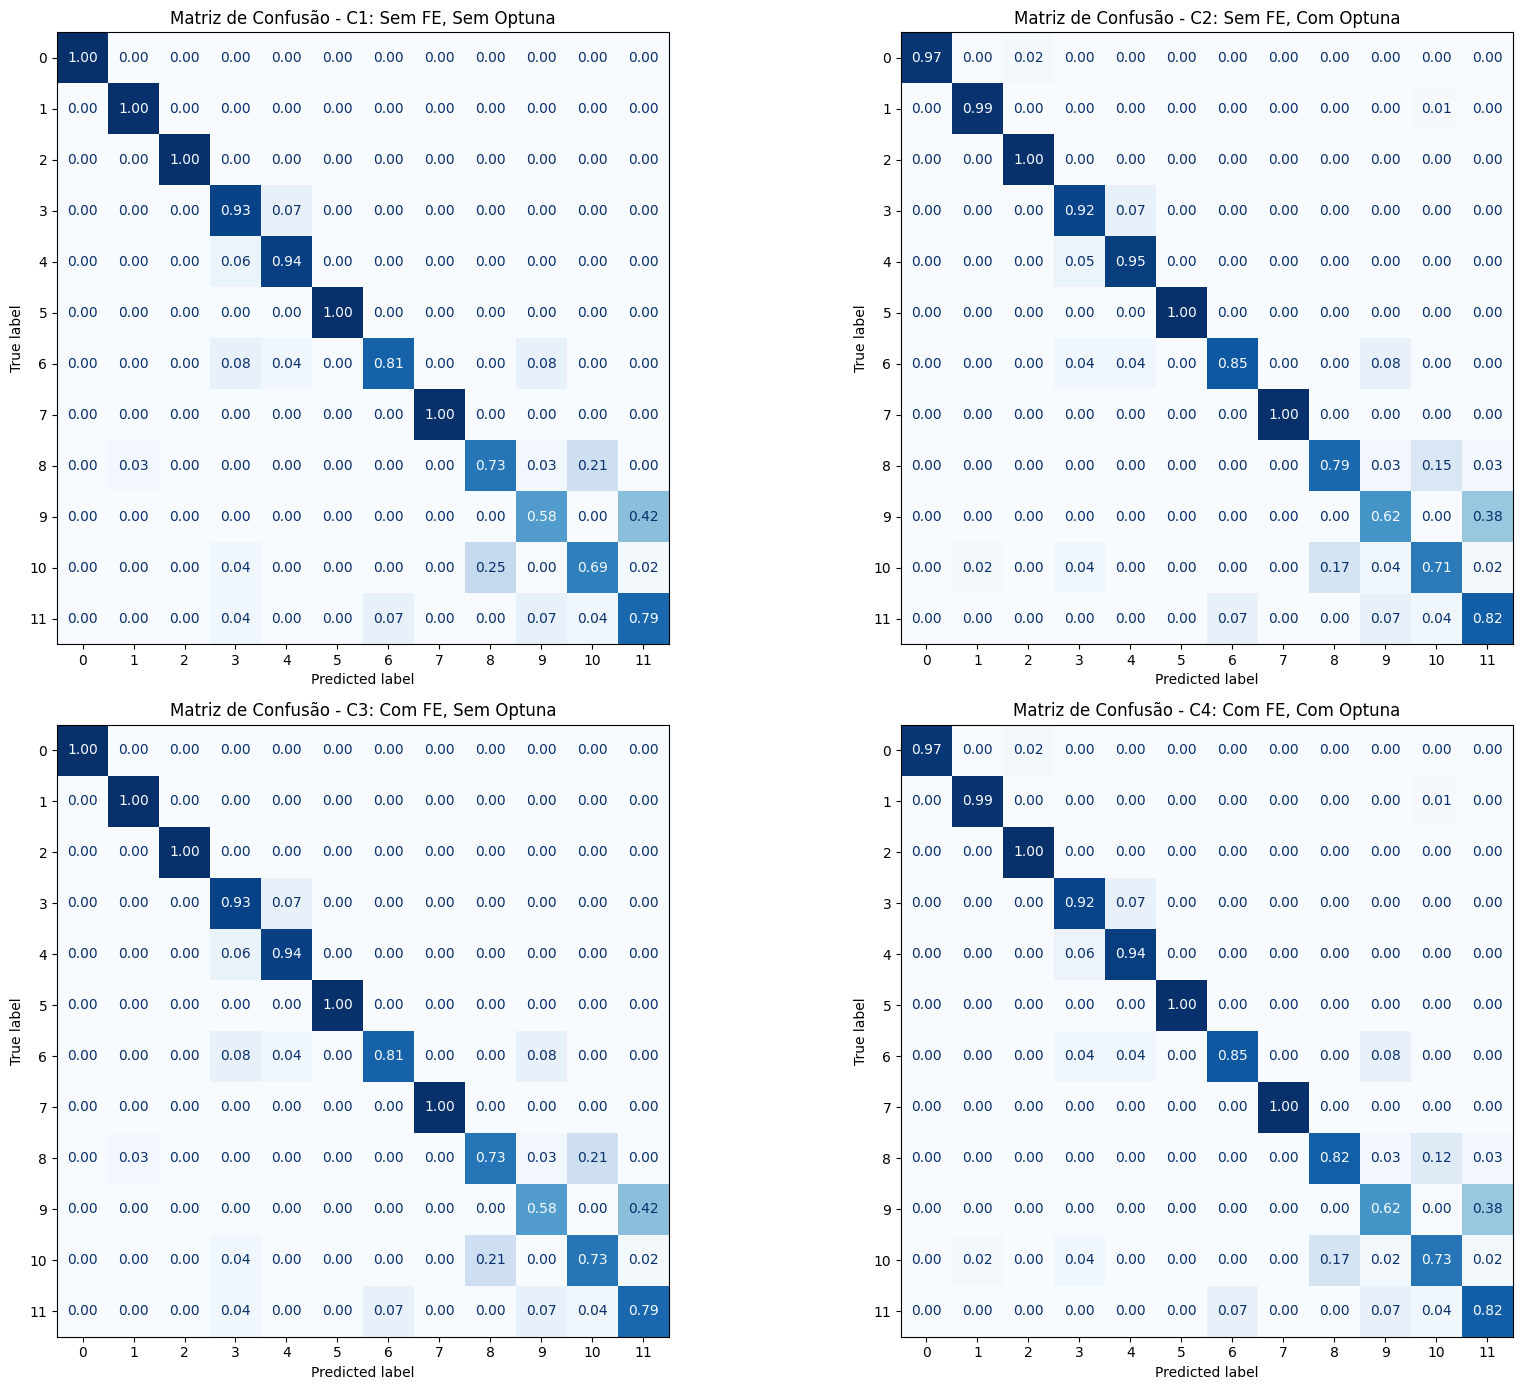


TABELA COMPARATIVA DE DESEMPENHO


,Cenário,Acurácia,Macro F1-Score
0,"C1: Sem FE, Sem Optuna",0.962137,0.874994
1,"C2: Sem FE, Com Optuna",0.959695,0.876798
2,"C3: Com FE, Sem Optuna",0.962443,0.878660
3,"C4: Com FE, Com Optuna",0.959389,0.880541


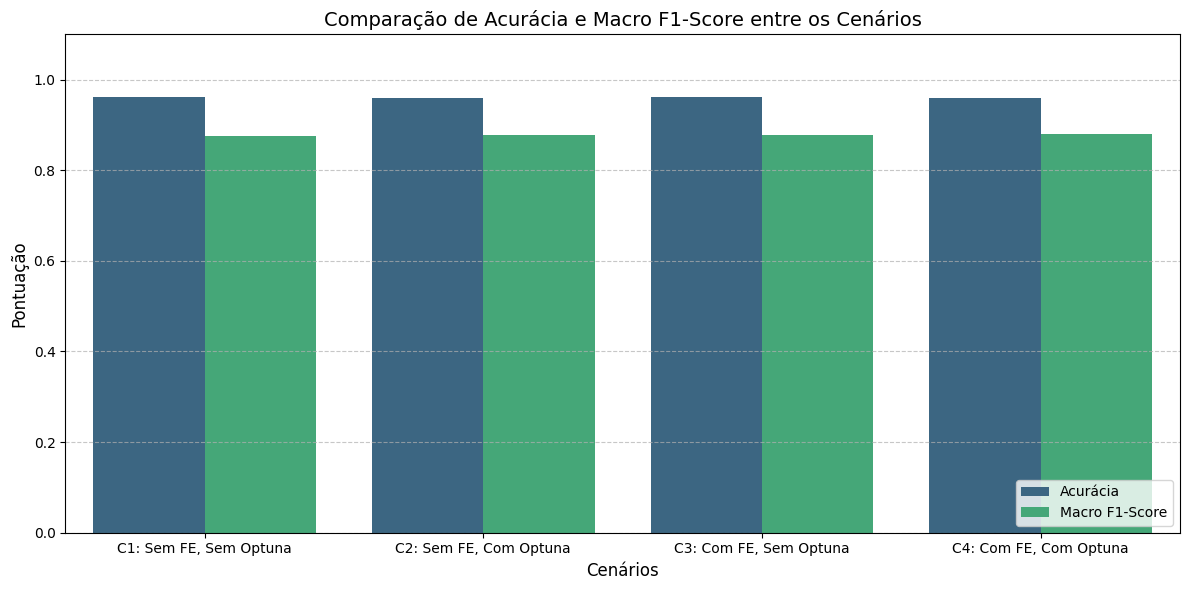

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay

# Agrupando as predições de teste de cada cenário
cenarios = {
    "C1: Sem FE, Sem Optuna": test_preds_s1,
    "C2: Sem FE, Com Optuna": test_preds_s2,
    "C3: Com FE, Sem Optuna": test_preds_s3,
    "C4: Com FE, Com Optuna": test_preds_s4
}

resultados = []

# 1. RELATÓRIOS DETALHADOS E MATRIZES DE CONFUSÃO
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (nome, preds) in enumerate(cenarios.items()):
    # Relatório de texto
    print(f"\n{'='*60}")
    print(f"RELATÓRIO DETALHADO: {nome}")
    print(f"{'='*60}")
    print(classification_report(y_test, preds))

    # Calculando e salvando métricas para a tabela
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    resultados.append({"Cenário": nome, "Acurácia": acc, "Macro F1-Score": f1})

    # Plot da Matriz de Confusão Normalizada
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        cmap='Blues',
        ax=axes[idx],
        normalize='true', # Matriz normalizada como solicitado
        colorbar=False,
        values_format='.2f'
    )
    axes[idx].set_title(f"Matriz de Confusão - {nome}")

plt.tight_layout()
plt.show()

# 2. TABELA COMPARATIVA
df_resultados = pd.DataFrame(resultados)
print("\n" + "="*60)
print("TABELA COMPARATIVA DE DESEMPENHO")
print("="*60)
display(df_resultados)

# 3. HISTOGRAMA / GRÁFICO DE BARRAS COMPARATIVO
# Transformando os dados para facilitar o plot com seaborn hue
df_melted = df_resultados.melt(id_vars='Cenário', var_name='Métrica', value_name='Pontuação')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Cenário', y='Pontuação', hue='Métrica', palette='viridis')
plt.title("Comparação de Acurácia e Macro F1-Score entre os Cenários", fontsize=14)
plt.ylim(0.0, 1.1) # Ajustando o eixo Y de 0 a 1
plt.ylabel("Pontuação", fontsize=12)
plt.xlabel("Cenários", fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
